<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
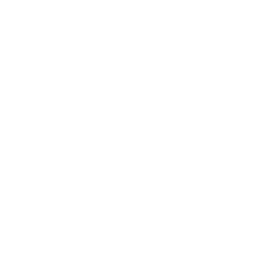
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Wirksamkeit des Detailings durch Außendienstmitarbeiter mit Lag-Auswahl</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharma- / Commercial-Analytics &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung für das Management

Bewerten Sie mit PROC AUTOREG den Einfluss von ärztlichen Detailing-Besuchen und der Musterverteilung auf das monatliche Verschreibungsvolumen eines Spezialpräparats. Berücksichtigen Sie autokorrelierte Verschreibungsmuster mit NLAG=3 und verwenden Sie die Option BACKSTEP, um nicht signifikante Lag-Ordnungen automatisch zu entfernen. Quantifizieren Sie den Grenzertrag jedes zusätzlichen Detailing-Besuchs, um Entscheidungen zum Einsatz des Außendienstes und zur Gebietsaufteilung zu fundieren.

Die synthetische Monatsreihe ist im aktuellen Ausführungsmodus auf 100 Beobachtungen begrenzt, was ausreicht, um die Effekte von Detailing, Musterabgabe, Formulary-Zugang und Wettbewerb mit hoher Präzision zu ermitteln.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.DETAILING | Monatliche Verschreibungen mit Detailing- und Musterkennzahlen | 100 |

---

In [1]:
/* --------------------------------------------------------
   Synthetische monatliche Außendienst- und Rx-Daten
   für ein Spezialpräparat erzeugen
   -------------------------------------------------------- */
DATEN work.detailing;
    AUFRUFEN streaminit(42);
    BEHALTEN_W prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    AUSFÜHRUNG month_seq = 1 BIS 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* Gebietszuweisung rotiert über 12 Außendienstmitarbeiter */
        rep_id = cat('REP-', PUT(mod(month_seq - 1, 12) + 1, z3.));
        /* Außendienstbesuche pro Monat */
        detail_visits = int(rand('normal', 8, 3));
        WENN detail_visits < 0 DANN detail_visits = 0;
        WENN detail_visits > 20 DANN detail_visits = 20;
        /* bei Ärzten hinterlassene Muster */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* Formularstatus der Krankenkasse (binär) */
        formulary_status = (rand('uniform') > 0.2);
        /* Druck durch Wettbewerberanteil */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* Saisonindex */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3)-Fehlerprozess */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* Verordnungsmodell */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        WENN new_rx < 0 DANN new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        AUSGABE;
    ENDE;
    ENTFERNEN prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    BEZEICHNUNG new_rx           = "Neue Verordnungen"
                total_rx         = "Verordnungen gesamt"
                detail_visits    = "Außendienstbesuche"
                samples_left     = "Hinterlassene Muster"
                competitor_share = "Wettbewerberanteil"
                formulary_status = "Formularstatus";
    format obs_month monyy7.;
AUSFÜHREN;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Deskriptive Basisstatistik für Rx und Außendienst
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.detailing n mean std MIN MAX;
    VAR new_rx total_rx detail_visits samples_left competitor_share;
    TITEL "Deskriptive Basisstatistik: Verordnungen und Außendienst";
AUSFÜHREN;

                                Deskriptive Basisstatistik: Verordnungen und Außendienst                                

                                                  The MEANS Procedure

 Variable          Label                        N            Mean        Std Dev        Minimum         Maximum
 --------------------------------------------------------------------------------------------------------------
 new_rx            Neue Verordnungen          100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Verordnungen gesamt        100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Außendienstbesuche         100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Hinterlassene Muster       100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Wettbewerberanteil         100       0.2653000      0.1187090      0.0300000       0.5600000
 ----------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                Deskriptive Basisstatistik: Verordnungen und Außendienst                                




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


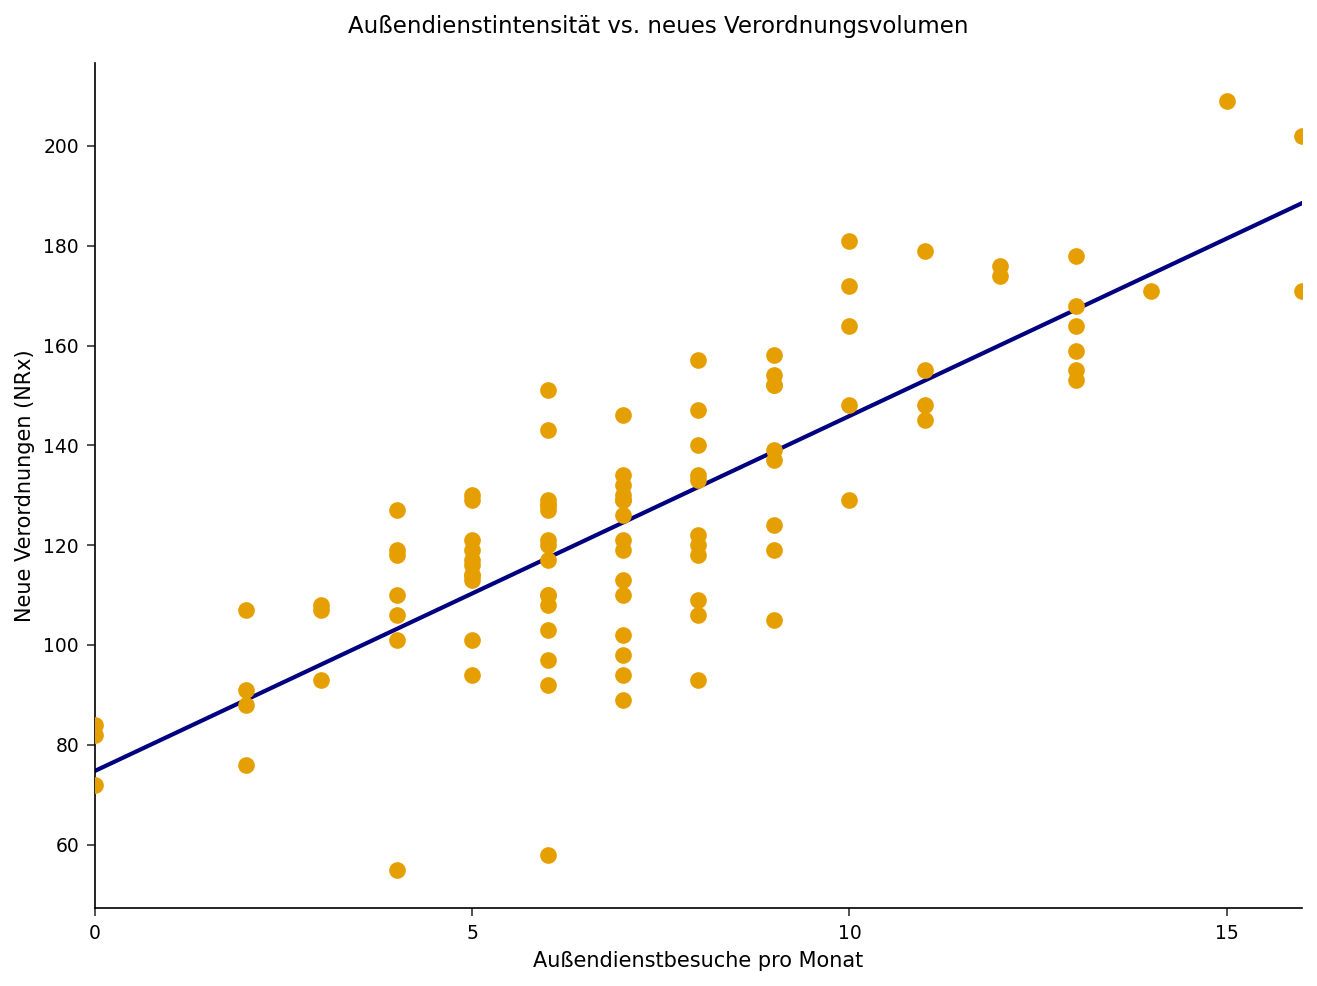

In [3]:
/* --------------------------------------------------------
   Streudiagramm: Außendienstbesuche vs. neue Verordnungen
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS BEZEICHNUNG="Außendienstbesuche pro Monat";
    YAXIS BEZEICHNUNG="Neue Verordnungen (NRx)";
    TITEL "Außendienstintensität vs. neues Verordnungsvolumen";
AUSFÜHREN;

---

In [4]:
/* --------------------------------------------------------
   Autoregressives Modell mit BACKSTEP-Lag-Auswahl anpassen.
   NLAG=3 prueft bis zu drei Lags; BACKSTEP entfernt nicht
   signifikante Lags automatisch.
   -------------------------------------------------------- */
PROZEDUR autoreg DATEN=work.detailing;
    MODELL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    AUSGABE out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
AUSFÜHREN;

                                Deskriptive Basisstatistik: Verordnungen und Außendienst                                


                     The AUTOREG Procedure

                     Dependent Variable   Neue Verordnungen


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Parameterschätzungen für die ROI-Berechnung erfassen
   -------------------------------------------------------- */
ODS AUSGABE parameterestimates=work.detail_params;

PROZEDUR autoreg DATEN=work.detailing;
    MODELL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
AUSFÜHREN;

ODS AUSGABE CLOSE;

                                Deskriptive Basisstatistik: Verordnungen und Außendienst                                


                     The AUTOREG Procedure

                     Dependent Variable   Neue Verordnungen


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Marginalen ROI je Außendienstbesuch berechnen.
   Der ODS-Datensatz ParameterEstimates speichert die Spalte
   Variable in Großbuchstaben, daher Filter auf 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROZEDUR DRUCKEN DATEN=work.detail_params;
    WO variable = 'DETAIL_VISITS';
    TITEL "Marginaler Effekt der Außendienstbesuche auf NRx";
AUSFÜHREN;

                                    Marginaler Effekt der Außendienstbesuche auf NRx                                    

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretation

PROC AUTOREG passte die Verschreibungsreihe an 100 monatliche Beobachtungen an. Jeder zusätzliche Detailing-Besuch ist mit **+2.72 neuen Verschreibungen pro Monat** verbunden (Schätzwert 2.7158, t = 7.66, p < 0.0001), und jede Einheit der bei Ärzten hinterlassenen Muster fügt **+1.00 NRx** hinzu (Schätzwert 0.9997, t = 14.73), was darauf hinweist, dass die Musterabgabe die persönliche Ansprache verstärkt, aber nicht ersetzt. Der Formulary-Zugang trägt **+24.78 NRx pro Monat** bei (t = 13.83) und unterstreicht den Managed-Care-Zugang als Voraussetzung für die Wirksamkeit des Detailings, während der Wettbewerbsanteil einen starken negativen Effekt von **-42.26 NRx pro Anteilseinheit** ausübt (t = -6.96) und Gebiete unter Wettbewerbsdruck kennzeichnet, in denen Detailing allein möglicherweise nicht ausreicht. Der Achsenabschnitt beträgt 69.56.

Mit NLAG=3 und BACKSTEP behielt das Modell **zwei autoregressive Lags**: Lag 1 (Koeffizient -0.3700, t = -3.78) und Lag 2 (Koeffizient -0.1995, t = -2.04); Lag 3 wurde als nicht signifikant entfernt. Die Durbin-Watson-Statistik nach der Korrektur beträgt **1.01**, liegt damit weiterhin deutlich unter 2 und signalisiert eine verbleibende positive Autokorrelation, sodass die AR(2)-Struktur einen Teil, aber nicht die gesamte serielle Abhängigkeit dieser Reihe erfasst. Anpassungsstatistiken: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, Log-Likelihood = -342.67.

Die Außendienstplanung sollte Gebiete mit günstigem Formulary-Zugang und moderatem Wettbewerbsanteil priorisieren, in denen der Grenzertrag jedes Detailing-Besuchs am höchsten ist.

---

In [7]:
/* --------------------------------------------------------
   Angepasste Werte und Parameter für das Außendienst-
   Planungsdashboard exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>